### HuyIGW04 - MNIST - Softmax Regression

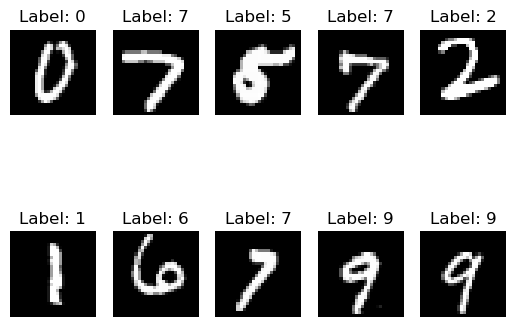

In [25]:
import torch
import torchvision
import matplotlib.pyplot as plt

# Define a function to load and plot MNIST images
def plot_mnist_images():
    # Load the MNIST dataset
    transform = torchvision.transforms.Compose([torchvision.transforms.ToTensor()])
    mnist_dataset = torchvision.datasets.MNIST(root='data', train=True, transform=transform, download=True)

    # Create a data loader to iterate through the dataset
    data_loader = torch.utils.data.DataLoader(mnist_dataset, batch_size=10, shuffle=True)

    # Plot the first 10 images from the dataset
    for images, labels in data_loader:
        for i in range(10):
            plt.subplot(2, 5, i + 1)
            plt.imshow(images[i].squeeze().numpy(), cmap='gray')
            plt.title(f'Label: {labels[i]}')
            plt.axis('off')
        plt.show()
        break  # Only plot the first batch

if __name__ == '__main__':
    plot_mnist_images()

In [26]:
import torchvision.transforms as transforms
import torch.nn as nn
# convert from PIL Image to Tensor
transform = transforms.Compose([transforms.ToTensor()])

# train set
train_set = torchvision.datasets.MNIST(root='data', transform=transform, train=True)
train_load = torch.utils.data.DataLoader(dataset=train_set, batch_size=100, shuffle=True)


# test set
test_set = torchvision.datasets.MNIST(root='data', transform=transform, train=False)
test_load = torch.utils.data.DataLoader(dataset=test_set, batch_size=1000, shuffle=False)

print(train_set.classes)

['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


In [27]:
input_features = 28*28           # img 28 x 28, num_feature = num_pixel
output_features = 10             # 10 classes


class SoftmaxRegression(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim).to('cuda')
    
    def forward(self, x):
        return self.linear(x)

model = nn.Sequential(
    nn.Flatten(),
    SoftmaxRegression(input_features, output_features)
)
model

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): SoftmaxRegression(
    (linear): Linear(in_features=784, out_features=10, bias=True)
  )
)

In [28]:
# constructor 
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.005)

losses = []
epochs = 6

# mini-batch training
for epoch in range(epochs):
    for i, (X, y) in enumerate(train_load):
        X = X.to('cuda')
        y = y.to('cuda')
        y_hat = model(X)
        loss_minibatch = loss(y_hat, y)
        losses.append(loss_minibatch.item())
        optimizer.zero_grad()
        loss_minibatch.backward()
        optimizer.step()

    # Print the loss every epoch
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss_minibatch.item():.4f}')

Epoch [1/6], Loss: 0.9665
Epoch [2/6], Loss: 0.7851
Epoch [3/6], Loss: 0.6377
Epoch [4/6], Loss: 0.5109
Epoch [5/6], Loss: 0.6765
Epoch [6/6], Loss: 0.5298


In [29]:
# Testing the model
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_load:
        images = images.to('cuda')
        labels = labels.to('cuda')
        outputs = model(images)
        predicted = torch.argmax(outputs.data, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    

    print(f'Accuracy on 10,000 test images: {100 * correct / total:.2f}%')

Accuracy on 10,000 test images: 88.19%


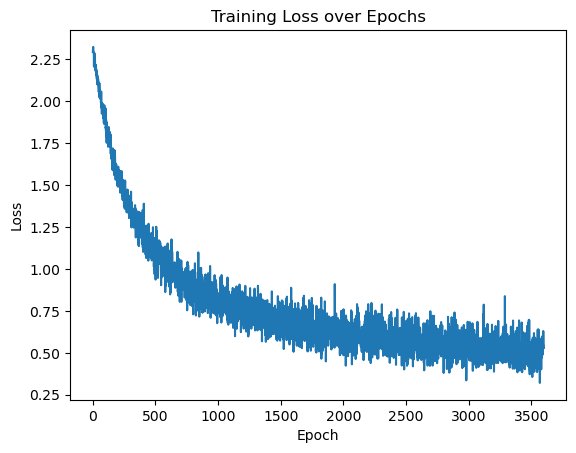

In [30]:
import matplotlib.pyplot as plt

# Plotting the loss
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.show()